In [23]:
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import TwoSlopeNorm

# ── Project root ─────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'MedGrid'))

import med_grid_env  # registers MedGrid-v0 and MedGrid-discrete-v0
import gymnasium as gym

# ── Run to analyse ───────────────────────────────────────────────────────────
RUN_NAME = 'medgrid_test_cont_run'   # change to match -info flag used during training
RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', RUN_NAME)

## 1. Ground truth regions

MedGrid is a **10×10** continuous gridworld with:
* **Red (Death):** quarter-circles of radius 3 at bottom-left $(0,0)$ and top-right $(10,10)$.
* **Yellow (Trap):** annular bands $3 < d \le 5$ around each death zone corner.
* **Blue (Recovery):** a rotated ellipse centred at $(5,5)$, semi-major $a=3$, semi-minor $b=1.5$, tilted $-45°$.
* **White (Neutral):** everything else.
* **Start:** bottom-right corner $(10, 0)$.

Rasterising region map (may take a moment)...


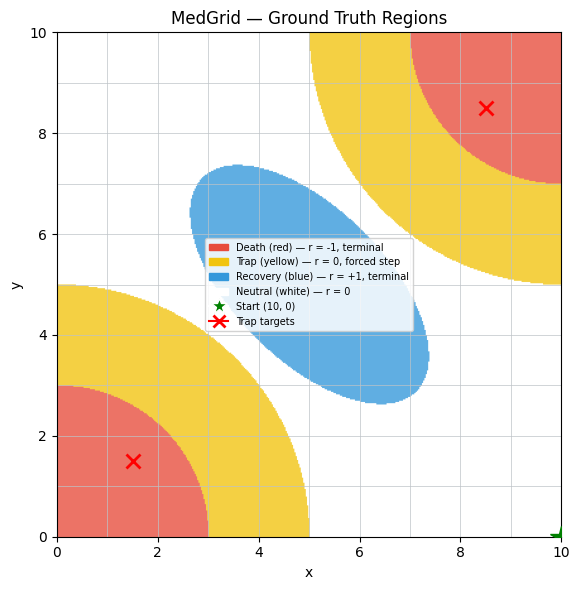

In [24]:
SIZE = 10.0
DEATH_R = 3.0
TRAP_R  = 5.0
ELLIPSE_A = 3.0
ELLIPSE_B = 1.5
RESOLUTION = 800   # pixels per axis for the rasterised background


def classify_point(x, y):
    """Return region label for a single (x, y) point."""
    d_bl = np.sqrt(x**2 + y**2)
    d_tr = np.sqrt((x - 10)**2 + (y - 10)**2)

    if d_bl <= DEATH_R or d_tr <= DEATH_R:
        return 'death'
    if d_bl <= TRAP_R or d_tr <= TRAP_R:
        return 'trap'
    dx, dy = x - 5.0, y - 5.0
    if ((dx - dy)**2 / (2 * ELLIPSE_A**2) + (dx + dy)**2 / (2 * ELLIPSE_B**2)) <= 1.0:
        return 'recovery'
    return 'neutral'


def build_region_image(resolution=RESOLUTION):
    """Rasterise the region map into an RGBA image for imshow."""
    COLORS = {
        'death':    np.array([231,  76,  60, 200], dtype=np.uint8),   # red
        'trap':     np.array([241, 196,  15, 200], dtype=np.uint8),   # yellow
        'recovery': np.array([ 52, 152, 219, 200], dtype=np.uint8),   # blue
        'neutral':  np.array([255, 255, 255, 255], dtype=np.uint8),   # white
    }
    xs = np.linspace(0, SIZE, resolution)
    ys = np.linspace(0, SIZE, resolution)
    img = np.zeros((resolution, resolution, 4), dtype=np.uint8)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            img[j, i] = COLORS[classify_point(x, y)]
    return img


def plot_ground_truth(ax=None, resolution=RESOLUTION):
    """Draw the MedGrid region layout. Returns (fig, ax)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    img = build_region_image(resolution)
    ax.imshow(img, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal')

    # 1-unit grid lines
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.5, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.5, zorder=2)

    # Trap forced-transition targets
    ax.plot(1.5, 1.5, 'rx', markersize=10, markeredgewidth=2,
            label='Trap1 target (1.5, 1.5)', zorder=4)
    ax.plot(8.5, 8.5, 'rx', markersize=10, markeredgewidth=2,
            label='Trap2 target (8.5, 8.5)', zorder=4)

    # Start position
    ax.plot(10, 0, 'g*', markersize=16, label='Start (10, 0)', zorder=5)

    # Legend patches
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label='Death (red) — r = -1, terminal'),
        mpatches.Patch(color='#f1c40f', label='Trap (yellow) — r = 0, forced step'),
        mpatches.Patch(color='#3498db', label='Recovery (blue) — r = +1, terminal'),
        mpatches.Patch(color='white',   label='Neutral (white) — r = 0'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='g',
                   markersize=12, label='Start (10, 0)'),
        plt.Line2D([0],[0], marker='x', color='r',
                   markersize=8, markeredgewidth=2, label='Trap targets'),
    ]
    ax.legend(handles=legend_patches, loc='center', fontsize=7,
              framealpha=0.85, bbox_to_anchor=(0.5, 0.5))

    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, SIZE)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('MedGrid — Ground Truth Regions')
    return fig, ax


print('Rasterising region map (may take a moment)...')
fig, ax = plot_ground_truth(resolution=400)
plt.tight_layout()
plt.show()

## 4. Sanity check — environment API

In [25]:
env = gym.make('MedGrid-v0')
obs, _ = env.reset()
print(f'Start state: {obs}  (expected [10. 0.])')

# Step directly into recovery zone (centre 5,5)
obs, r, term, trunc, _ = env.step(np.array([5.0, 5.0]))
print(f'Step to (5,5): obs={obs}, reward={r}, terminated={term}  (expect +1, True)')

# Reset and step into death zone BL
obs, _ = env.reset()
obs, r, term, trunc, _ = env.step(np.array([1.0, 1.0]))
print(f'Step to (1,1): obs={obs}, reward={r}, terminated={term}  (expect -1, True)')

# Reset and step into Trap1, then verify forced transition
obs, _ = env.reset()
obs, r, term, trunc, _ = env.step(np.array([4.0, 0.5]))   # inside Trap1 band
print(f'Step to BL trap (4.0,0.5): obs={obs}, reward={r}, terminated={term}  (expect 0, False)')
obs2, r2, term2, trunc2, _ = env.step(np.array([8.0, 8.0]))  # action ignored
print(f'Forced from Trap1:          obs={obs2}, reward={r2}, terminated={term2}  (expect [1.5 1.5], -1, True)')

env.close()

Start state: [10.  0.]  (expected [10. 0.])
Step to (5,5): obs=[5. 5.], reward=1.0, terminated=True  (expect +1, True)
Step to (1,1): obs=[1. 1.], reward=-1.0, terminated=True  (expect -1, True)
Step to BL trap (4.0,0.5): obs=[4.  0.5], reward=0.0, terminated=False  (expect 0, False)
Forced from Trap1:          obs=[1.5 1.5], reward=-1.0, terminated=True  (expect [1.5 1.5], -1, True)


## 5. Discrete wrapper sanity check

In [26]:
env_d = gym.make('MedGrid-discrete-v0', n_bins=11)
obs, _ = env_d.reset()
print(f'Discrete action space size (n_bins=11): {env_d.action_space.n}  (expect 121)')
print(f'Observation space: {env_d.observation_space}')
env_d.close()

Discrete action space size (n_bins=11): 121  (expect 121)
Observation space: Box(0.0, 10.0, (2,), float32)


## 6. Load trained agents (after training)

Run training first:
```bash
cd toy_domain
../.venv/bin/python run.py -env MedGrid -action_mode discrete -n_bins 11 \
    -agent iqn -ded -frames 500000 -info medgrid_iqn
```

In [27]:
import io

RUN_NAME = 'medgrid_test_cont'   # change to match -info flag used during training
RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', RUN_NAME)


class CpuUnpickler(pickle.Unpickler):
    """Unpickler that maps CUDA-backed torch storages onto CPU."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(
                io.BytesIO(b), map_location=torch.device('cpu'), weights_only=False
            )
        return super().find_class(module, name)


def load_pickle_cpu(path):
    with open(path, 'rb') as f:
        return CpuUnpickler(f).load()


agent, qd, qr = None, None, None
try:
    agent = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_agent.pkl'))
    print('Loaded main agent')
    qd = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qd.pkl'))
    qr = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qr.pkl'))
    print('Loaded Qd and Qr networks')
except FileNotFoundError as e:
    print(f'Agents not found ({e}) - train first with the command above.')
except RuntimeError as e:
    print(f'Failed to load agents due to runtime error: {e}')

Loaded main agent
Loaded Qd and Qr networks


## 7. CVaR Q-value heatmaps over action space at state (5, 0)

For a fixed start-region state we sweep the 10×10 action space and compute the
**lower CVaR** of the IQN quantile distribution at each action.

Only runs if agents were loaded above.

CVaR: keeping 6/32 quantiles (eta=0.2)
Randomly sampling 10000 actions for state [10.0, 0.0]
Computing Qd scatter...
  range: [-1.098, -0.014]
Computing Qr scatter...
  range: [-0.038, 1.012]


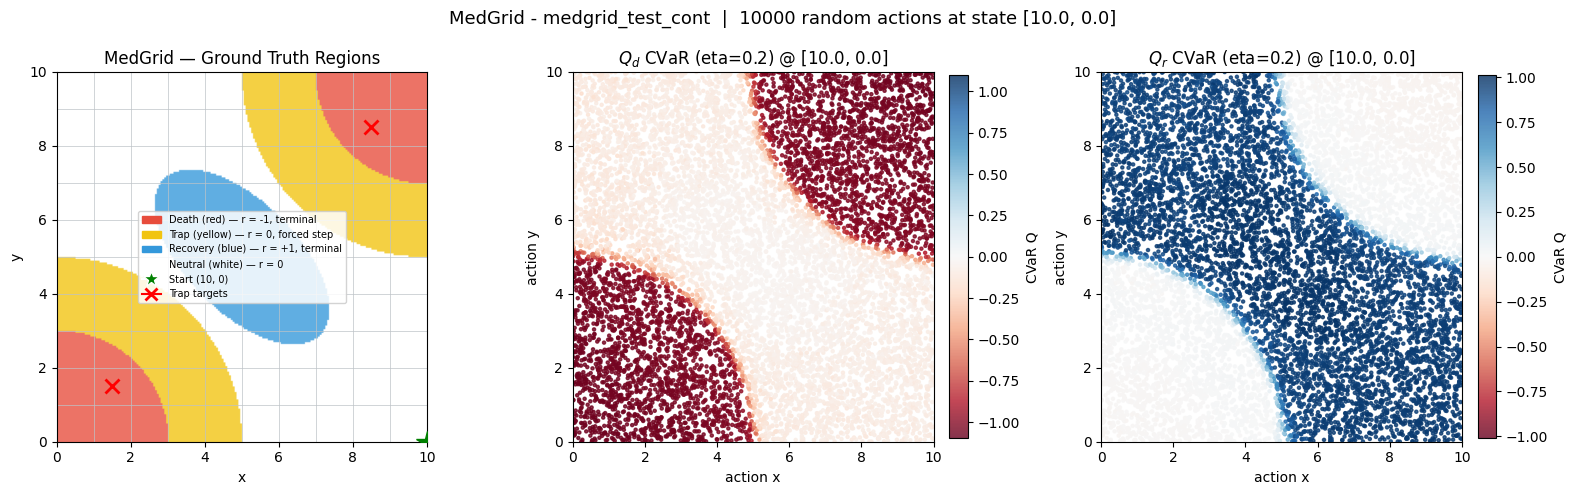

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_test_cont/medgrid_ded_action_scatter.png


In [ ]:
N_ACTIONS = 10000
N_TAU = 32
alpha   = 0.2
DEVICE = 'cpu'
FIXED_STATE = [10.0, 0.0]   # start corner

N_KEEP = max(1, int(alpha * N_TAU))
print(f'CVaR with alpha={alpha})')
print(f'Randomly sampling {N_ACTIONS} actions for state {FIXED_STATE}')


def _prepare_iqn_for_device(ded_agent, device):
    network = ded_agent.qnetwork_local
    network.to(device)
    network.device = device
    if hasattr(network, 'pis'):
        network.pis = network.pis.to(device)
    return network


def compute_action_scatter(ded_agent, state=FIXED_STATE, n_actions=N_ACTIONS,
                            n_tau=N_TAU, eta=alpha, device=DEVICE, seed=42):
    rng = np.random.default_rng(seed)
    actions = rng.uniform(0.0, 10.0, size=(n_actions, 2)).astype(np.float32)

    s = np.array([state], dtype=np.float32)
    states = np.tile(s, (n_actions, 1))

    n_keep = max(1, int(eta * n_tau))
    network = _prepare_iqn_for_device(ded_agent, device)
    network.eval()

    s_t = torch.from_numpy(states).to(device)
    a_t = torch.from_numpy(actions).to(device)

    with torch.no_grad():
        quantiles, _ = network.forward(s_t, a_t, num_tau=n_tau)

    q = quantiles.squeeze(-1).cpu().numpy()
    q_sorted = np.sort(q, axis=1)
    cvar = q_sorted[:, :n_keep].mean(axis=1)
    return cvar, actions


def plot_action_scatter(cvar, actions, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure
    vmax = max(np.abs(cvar).max(), 1e-6)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    sc = ax.scatter(actions[:, 0], actions[:, 1], c=cvar,
                    cmap='RdBu', norm=norm, s=5, alpha=0.8)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label='CVaR Q')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(title)
    return fig, ax


if qd is not None and qr is not None:
    print('Computing Qd scatter...')
    cvar_d, actions_d = compute_action_scatter(qd)
    print(f'  range: [{cvar_d.min():.3f}, {cvar_d.max():.3f}]')

    print('Computing Qr scatter...')
    cvar_r, actions_r = compute_action_scatter(qr)
    print(f'  range: [{cvar_r.min():.3f}, {cvar_r.max():.3f}]')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    plot_ground_truth(ax=axes[0], resolution=200)
    plot_action_scatter(cvar_d, actions_d,
                        title=f'$Q_d$ CVaR (eta={alpha}) @ {FIXED_STATE}', ax=axes[1])
    plot_action_scatter(cvar_r, actions_r,
                        title=f'$Q_r$ CVaR (eta={alpha}) @ {FIXED_STATE}', ax=axes[2])
    fig.suptitle(f'MedGrid - {RUN_NAME}  |  {N_ACTIONS} random actions at state {FIXED_STATE}', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(RUN_DIR, 'medgrid_ded_action_scatter.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped - no trained agents loaded.')
